In [10]:
import pandas as pd
import xgboost as xgb
import numpy as np
import optuna
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

In [3]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Augmented (Secondly) Dataset.csv')

In [4]:
# Drop diseases with less than 1000 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 1000].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 37
Number of rows left: 44748


In [5]:
# Instead, calculate class weights inversely proportional to class frequencies
class_counts = pd.Series(y_train).value_counts()
total_samples = len(y_train)
class_weights = {class_idx: total_samples / (len(class_counts) * count) 
                for class_idx, count in class_counts.items()}

In [8]:
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': len(np.unique(y_train)),
        'tree_method': 'hist',
        'eval_metric': 'mlogloss',
        
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        
        # Try including early stopping directly in the model parameters
        'early_stopping_rounds': 50,
    }
    
    # Create XGBoost model with parameters from Optuna
    model = xgb.XGBClassifier(**params)
    
     # Create sample_weight array based on class weights
    sample_weight = np.array([class_weights[y] for y in y_train])
    
    model.fit(
        X_train,  # Use original training data instead of resampled
        y_train,  # Use original labels instead of resampled
        eval_set=[(X_test, y_test)],
        sample_weight=sample_weight,  # Add sample weights
        verbose=False
    )
    
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return accuracy

In [10]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="XGboost_diseases_symptoms_dropextremelymore1000withoutSMOTE_augmented_study", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/xgboost.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=20)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-23 12:41:41,754] A new study created in RDB with name: XGboost_diseases_symptoms_dropextremelymore1000withoutSMOTE_augmented_study
[I 2025-04-23 12:43:02,185] Trial 0 finished with value: 0.8426815642458101 and parameters: {'max_depth': 14, 'learning_rate': 0.17885451326495483, 'n_estimators': 871, 'subsample': 0.5287750309216273, 'colsample_bytree': 0.8005749008149889, 'gamma': 0.057477373764707185, 'reg_alpha': 2.3646537104241565, 'reg_lambda': 1.7609496554185522}. Best is trial 0 with value: 0.8426815642458101.
[I 2025-04-23 12:43:36,322] Trial 1 finished with value: 0.850391061452514 and parameters: {'max_depth': 3, 'learning_rate': 0.25648220692290696, 'n_estimators': 467, 'subsample': 0.9374318524237173, 'colsample_bytree': 0.7845105146918849, 'gamma': 0.874425312492535, 'reg_alpha': 4.292224015212897, 'reg_lambda': 4.3019307276822625}. Best is trial 1 with value: 0.850391061452514.
[I 2025-04-23 12:44:24,845] Trial 2 finished with value: 0.8470391061452514 and paramet


Best Trial:
FrozenTrial(number=11, state=TrialState.COMPLETE, values=[0.8519553072625698], datetime_start=datetime.datetime(2025, 4, 23, 12, 50, 45, 756907), datetime_complete=datetime.datetime(2025, 4, 23, 12, 52, 15, 587991), params={'max_depth': 6, 'learning_rate': 0.01462555827798726, 'n_estimators': 436, 'subsample': 0.6782557346224011, 'colsample_bytree': 0.5086820205905804, 'gamma': 0.23982502686778995, 'reg_alpha': 4.9246817175898645, 'reg_lambda': 1.2879000779782652}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'max_depth': IntDistribution(high=15, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=False, low=0.01, step=None), 'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'gamma': FloatDistribution(high=5.0, log=False, low=0.0, step=None), 'reg_alph

Model has been trained and saved successfully.


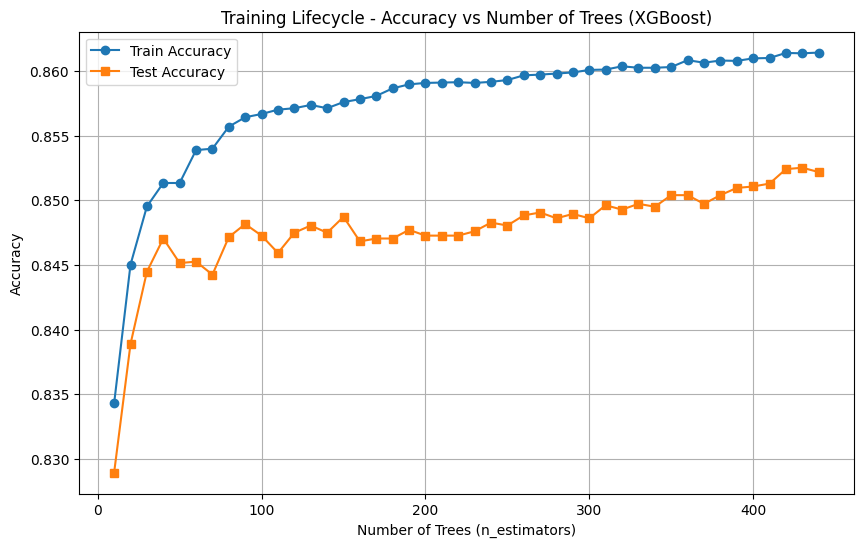

In [9]:
# Load Optuna study
study = optuna.load_study(
    study_name="XGboost_diseases_symptoms_dropextremelymore1000withoutSMOTE_augmented_study",
    storage="sqlite:///C:/Users/khiew/Downloads/xgboost.db"
)

# Get best parameters
best_params = study.best_trial.params

# Create a base model using best parameters
best_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_train)),
    tree_method='hist',
    eval_metric='mlogloss',
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    n_estimators=best_params['n_estimators'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    random_state=42
)

# Create sample_weight array based on class weights
sample_weight = np.array([class_weights[y] for y in y_train])

# Train the model
best_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weight,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Save the trained model
joblib.dump(best_model, r'C:\Users\khiew\Downloads\first_best_xgboost_model.joblib')

print("Model has been trained and saved successfully.")

# ============================
# Plotting Training Lifecycle
# ============================

# Simulate the effect of n_estimators (trees)
n_estimators_list = list(range(10, best_params['n_estimators']+10, 10))  # steps of 10 trees
train_accuracies = []
test_accuracies = []

for n in n_estimators_list:
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y_train)),
        tree_method='hist',
        eval_metric='mlogloss',
        max_depth=best_params['max_depth'],
        learning_rate=best_params['learning_rate'],
        n_estimators=n,
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        gamma=best_params['gamma'],
        reg_alpha=best_params['reg_alpha'],
        reg_lambda=best_params['reg_lambda'],
        random_state=42
    )
    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weight,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    # Train accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(n_estimators_list, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(n_estimators_list, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Training Lifecycle - Accuracy vs Number of Trees (XGBoost)')
plt.legend()
plt.grid(True)
plt.show()